---

**Task**

- 결측치가 존재하는 데이터셋에 대한 시계열 예측 및 평가 분석 진행

**Dataset**

- 기존 벤치마크 데이터셋(ETTh1)에서 인덱스 및 결측치 추가하여 전달
- 결측치 여부는 사전에 공개하지 않음

**Code**

- 기본적인 코드 틀 대신 프레임워크 구성 가능 여부 확인
- 데이터 분석 및 전처리 - 데이터셋 및 로더 구성 - 모델 구축 및 학습 - 성능 평가 및 결과 해석
- 기존 모델 코드 그대로 사용 금지

**Submit**

- 모든 과정에 대한 명확한 근거와 설명 문서화
- 실험 결과의 로깅 및 시각화
- 제출 파일은 README, 주피터 노트북 형태로 개인 repo에 push 한 다음 repo 링크를 제출

**Dataset**

---

## 0. 초기 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/Colab Notebooks'

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks')

['Titanic1~2.ipynb',
 'Titanic4.ipynb',
 'Titanic5.ipynb',
 'Titanic6.ipynb',
 'Untitled',
 'Review.ipynb',
 'SHAP.ipynb',
 'Isolation Forest',
 'Population.R',
 'Untitled0.ipynb',
 'dataset',
 'saved_model',
 'DSBA_Time-series 석사 코딩테스트.ipynb의 사본']

In [3]:
os.listdir('/content/drive/MyDrive/Colab Notebooks/dataset/ETT-small')

['ETTh1_adjust.csv']

In [4]:
# 필요 라이브러리 설치
!pip install omegaconf

In [5]:
# 기본 라이브리러리
import torch
from torch.utils.data import DataLoader

import numpy as np
import os
import json
import shutil
import logging
import warnings
warnings.filterwarnings("ignore")

from glob import glob

from accelerate import Accelerator, DistributedDataParallelKwargs
from accelerate.logging import get_logger
from accelerate.utils import set_seed

from omegaconf import OmegaConf

################### 추가 라이브러리(이용시) ######################
import time
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
############################################################

In [6]:
# Training argument
config = {
    "DEFAULT": {
        "exp_name": "ETTh1_adjust_96_96_standard",
        "seed": 42 #재현성
    },
    "DATASET": {
        "taskname": "long_term_forecast",
        "dataname": "custom",
        "sub_data_name": None,
        "scaler": "standard", #StandardScaler 정규화
        "window_size": 96, #입력 96시간
        "label_len": 0,
        "pred_len": 96, #예측 96시간
        "model_type": "forecasting",
        "pretrain": False,
        "split_rate": [0.7, 0.1, 0.2], #train/valid/test 7:1:2
        "timeenc": 0,
        "freq": "h", #시간단위(h) 데이터
        "embed_type": "learned"
    },
    "DATAINFO": {
        "datadir": "/content/drive/MyDrive/Colab Notebooks/dataset/ETT-small/ETTh1_adjust.csv",
        "train_path": "",
        "valid_path": "",
        "test_path": "",
        "test_label_path": ""
    },
    "TRAIN": {
        "epoch": 30,
        "batch_size": 64,
        "test_batch_size": 128,
        "num_workers": 0,
        "ckp_metric": "MSE",
        "eval_epochs": 1,
        "log_epochs": 1,
        "log_eval_iter": 50,
        "shuffle": False,
        "pin_memory": True,
        "resume": False,
        "resume_number": 0,
        "early_stopping_metric": "loss",
        "early_stopping_count": 20,
        "return_output": True,
        "lradj": "type1",
        "wandb": {
            "use": False,
            "iter": 50,
            "exp_name": "default",
            "project_name": "TMAE",
            "entity": "jinwoo"
        }
    },
    "LOSS": {
        "loss_name": "MSELoss"
    },
    "OPTIMIZER": {
        "opt_name": "AdamW",
        "lr": 0.0001,
        "params": {
            "weight_decay": 0.0005
        }
    },
    "RESULT": {
        "savedir": "./saved_model"
    }
}

# Model arguments
models_config = {
##################### EDIT YOUR CODE #########################
"PatchTST": {
        "patch_len": 16,   # 패치 하나 길이 (96시간을 16시간 조각으로 자름)
        "stride": 8,       # 패치 간격 (8칸씩 이동 → 패치끼리 절반 겹침)
        "d_model": 128,    # 각 패치를 128차원 벡터로 임베딩
        "n_heads": 8,      # 어텐션 헤드 수 (여러 관점으로 패치 관계 학습)
        "e_layers": 3,     # 트랜스포머 인코더 층 수
        "d_ff": 256,       # 인코더 내부 FFN 은닉 크기
        "dropout": 0.1,    # 과적합 방지용 드롭아웃 비율
    }
##############################################################
}

cfg = OmegaConf.create(config)

##################### EDIT YOUR CODE #########################
cfg = OmegaConf.merge(cfg, {'MODEL':{'modelname' : 'PatchTST'}})
##############################################################

model_cfg = OmegaConf.create(models_config)
modelname = cfg.MODEL.modelname

if modelname in model_cfg:
    model_setting_conf = OmegaConf.create(model_cfg[cfg.MODEL.modelname])
    cfg = OmegaConf.merge(cfg, {'MODELSETTING' : model_setting_conf})
else:
    print(f"Model '{modelname}' not found in the model_config.")


---

In [7]:
def make_save(accelerator, savedir: str, resume: bool = False) -> str:
    # resume
    if resume:
        assert os.path.isdir(savedir), f'{savedir} does not exist'
        # check version
        version = len([f for f in glob.glob(os.path.join(savedir, '*')) if os.path.isdir(f)])
        # init version
        if version == 0:
            files = [f for f in glob.glob(os.path.join(savedir, '*')) if os.path.isfile(f)]
            version0_dir = os.path.join(savedir, f'train{version}')

            accelerator.wait_for_everyone()
            if accelerator.is_main_process:
                os.makedirs(version0_dir)
                for f in files:
                    shutil.move(f, f.replace(savedir, version0_dir))
            version += 1

        savedir = os.path.join(savedir, f'train{version}')
    accelerator.wait_for_everyone()
    if accelerator.is_main_process:
        os.makedirs(savedir, exist_ok=True)
    print("make save directory {}".format(savedir))

    return savedir


In [8]:
_logger = get_logger('train')

# set seed
set_seed(cfg.DEFAULT.seed)

# set accelrator
accelerator = Accelerator()

logging.basicConfig(
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    datefmt="%m/%d/%Y %H:%M:%S",
    level=logging.INFO,
    )

# make save directory
savedir = os.path.join(cfg.RESULT.savedir, cfg.MODEL.modelname, cfg.DEFAULT.exp_name)
savedir = make_save(accelerator = accelerator, savedir=savedir, resume=cfg.TRAIN.resume)

# set device
_logger.info('Device: {}'.format(accelerator.device), main_process_only=False)

make save directory ./saved_model/PatchTST/ETTh1_adjust_96_96_standard


## 1. 데이터 분석 및 전처리

    1-1) 제공된 데이터에 기본적인 분석 진행 (통계량 분석, 결측치 확인, 정상성 분석, 시계열 분해 등)
    1-2) 확인된 특성을 반영하여 전처리 진행 (이상치 처리, 결측치 처리, 정규화 등)
    1-3) 전처리된 데이터를 바탕으로 다시 한번 분석 진행 후 수정된 부분 기술 (통계량 분석, 결측치 확인, 정상성 분석, 시계열 분해 등)
    1-4) 수정 내용을 반영하며, create_dataloader_default에 기술된 argument가 포함될 수 있도록 함수 작성
    1-5) Argument가 기재된 의도를 파악하여 최대한 많은 argument사용하여 작성
    1-6) Pytorch 라이브러리를 통하여 모델링 가능하게끔 데이터셋 구성 및 로더 구성
    1-7) 데이터셋 구성 중, 간격이 달라지는 시점이 존재한다면 해당 부분은 데이터셋으로 구성되지 않도록 구성

(14184, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14184 entries, 0 to 14183
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    14184 non-null  object 
 1   HUFL    14184 non-null  float64
 2   HULL    14184 non-null  float64
 3   MUFL    14184 non-null  float64
 4   MULL    14184 non-null  float64
 5   LUFL    14184 non-null  float64
 6   LULL    14184 non-null  float64
 7   OT      14184 non-null  float64
dtypes: float64(7), object(1)
memory usage: 886.6+ KB
None
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948

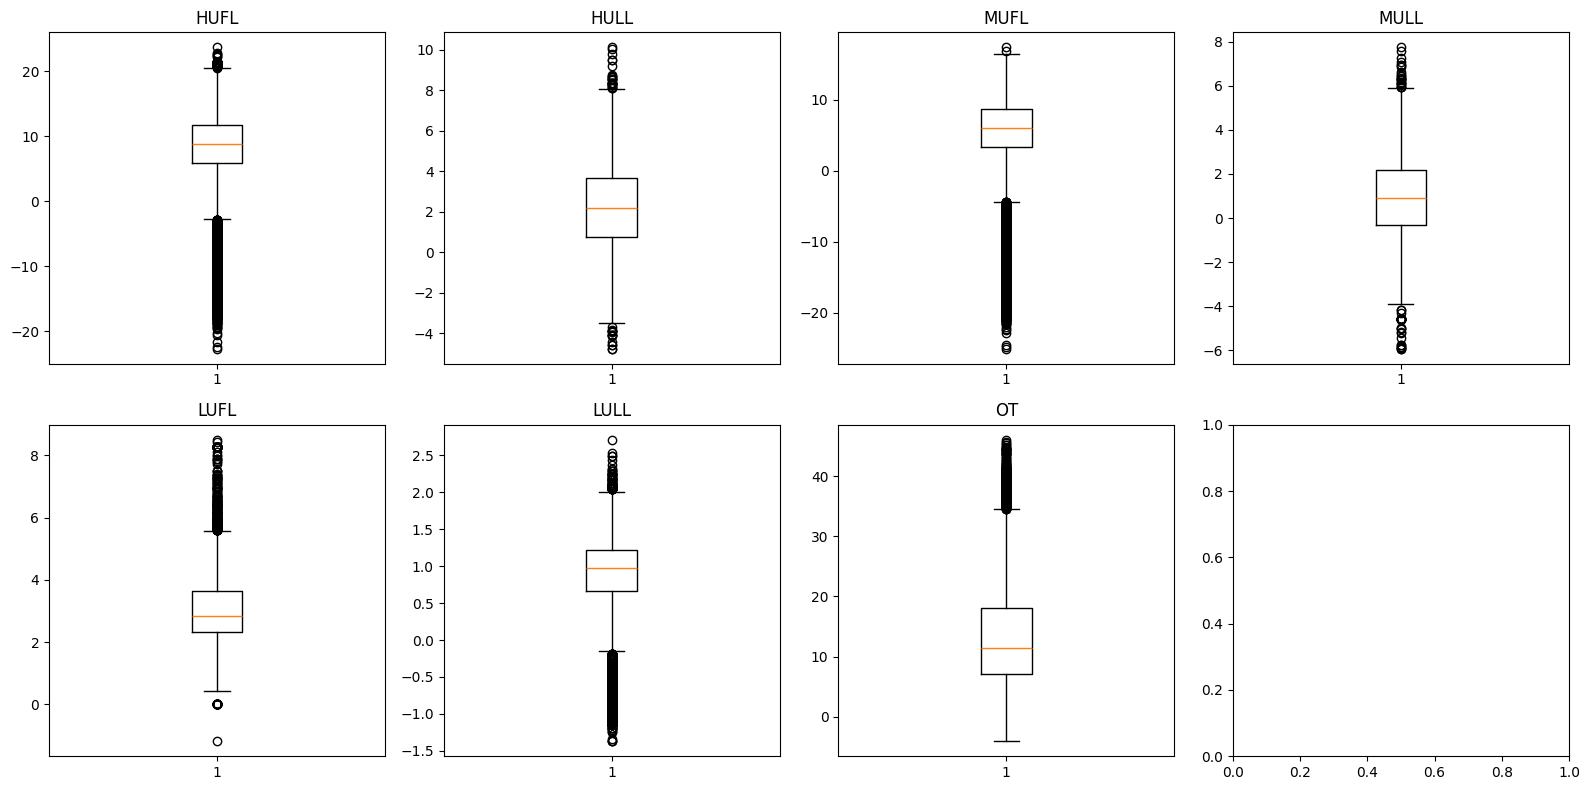

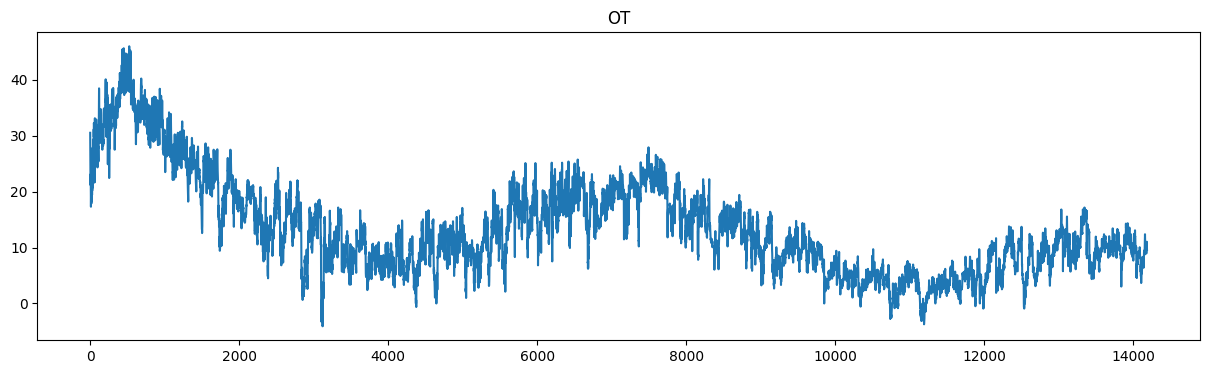

date
0 days 01:00:00    13610
0 days 06:00:00      473
0 days 08:00:00       21
0 days 10:00:00       19
0 days 11:00:00       18
0 days 09:00:00       17
0 days 07:00:00       13
0 days 12:00:00        4
0 days 16:00:00        4
0 days 13:00:00        2
0 days 14:00:00        1
0 days 19:00:00        1
Name: count, dtype: int64
HUFL 1489 1441 48
HULL 40 15 25
MUFL 1628 1626 2
MULL 66 42 24
LUFL 435 41 394
LULL 1393 1324 69
OT 395 0 395
HUFL: ADF p=0.0000
HULL: ADF p=0.0000
MUFL: ADF p=0.0000
MULL: ADF p=0.0000
LUFL: ADF p=0.0000
LULL: ADF p=0.0000
OT: ADF p=0.0056


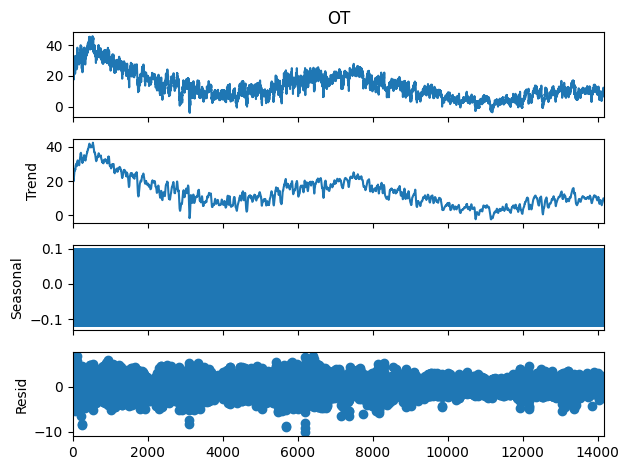

기준 6시간 초과만 경계 → 192이상 구간: 27개, 생성 윈도우: 3382개
기준 7시간 초과만 경계 → 192이상 구간: 27개, 생성 윈도우: 4253개
기준 8시간 초과만 경계 → 192이상 구간: 28개, 생성 윈도우: 5911개
기준 10시간 초과만 경계 → 192이상 구간: 20개, 생성 윈도우: 9409개
기준 12시간 초과만 경계 → 192이상 구간: 9개, 생성 윈도우: 12465개
기준 24시간 초과만 경계 → 192이상 구간: 1개, 생성 윈도우: 13993개
기준 48시간 초과만 경계 → 192이상 구간: 1개, 생성 윈도우: 13993개


In [9]:
# 1-1~3 항목의 EDA 코드 작성
################### EDIT YOUR CODE #########################
path = '/content/drive/MyDrive/Colab Notebooks/dataset/ETT-small/ETTh1_adjust.csv'
df = pd.read_csv(path)

# 1-1. 데이터 분석
print(df.shape)
print(df.info())
print(df.head())
print(df.describe())

# boxplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, df.columns[1:]):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

# OT 시계열
plt.figure(figsize=(15, 4))
plt.plot(df['OT'])
plt.title('OT')
plt.show()

# 결측 확인 (시간 끊김 = 행 삭제)
date = pd.to_datetime(df['date'])
diff = date.diff()
print(diff.value_counts())

# IQR 이상치 개수
for col in df.columns[1:]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    low = (df[col] < lower).sum()
    high = (df[col] > upper).sum()
    print(col, outlier, low, high)

# [이상치 처리 결정] 제거하지 않음
# - OT(타겟): 이상치 395개가 전부 상한(하한 0). 대칭 노이즈가 아니라
#   한 방향 극값 → 전력 수요 피크(실제 신호)로 판단
# - IQR로 제거하면 타겟의 피크 정보를 통째로 손실 → 예측에 치명적
# - Informer 원논문도 ETT 이상치 미제거

# 정상성
for col in df.columns[1:]:
    stat, p = adfuller(df[col])[:2]
    print(f"{col}: ADF p={p:.4f}")

# 분해
seasonal_decompose(df['OT'], model='additive', period=24).plot()
plt.show()

# [1-1 결과]
# - 결측: NaN 아니라 시간 행 삭제, 573군데, 간격 6~19시간 불규칙
# - 정상성: OT ADF p=0.0056 → 정상
# - 분해: 24시간 주기 기준 분해에서 trend 성분이 크고 seasonal은 상대적으로 작음
#   (주기를 24h만 봤으므로 "계절성이 없다"고 단정하진 않음)
# - 이상치: IQR상 존재하나 실제 전력 수요 피크로 판단

# [1-2 결정]
# (1) 이상치: 제거 안 함 → 위 IQR 결정 주석 참고
# (2) 결측: 아래 '기준별 window 실험'으로 8시간 선택 → 다음 셀에서 실제 보간
# (3) 정규화: create_dataloader_default 안에서 StandardScaler (train만 fit)
window_size = 96
pred_len = 96
min_len = window_size + pred_len  # 192

for hours in [6, 7, 8, 10, 12, 24, 48]:
    big_gap = diff[diff > pd.Timedelta(hours=hours)].index
    boundaries = [0] + list(big_gap) + [len(df)]
    seg = pd.Series([boundaries[i+1] - boundaries[i] for i in range(len(boundaries)-1)])
    valid_segs = seg[seg >= min_len]
    n_windows = (valid_segs - min_len + 1).sum()
    print(f"기준 {hours}시간 초과만 경계 → 192이상 구간: {len(valid_segs)}개, 생성 윈도우: {n_windows}개")

# [결측 결정] 8시간 이하 gap 보간 / 초과는 window 경계로 제외
# - 8h 선택: 6h는 학습 window 부족, 10h+(9409개)는 장거리 보간 비율↑로 왜곡 위험 증가
#   → window 확보와 왜곡 위험 사이 균형점으로 8h 선택

In [10]:
# 1-2. 결측치 보간
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'])

# 나중에 윈도우 단계에서 쓸 gap 경계 미리 기록 (8시간 초과 지점)
diff = df['date'].diff()
long_gap_dates = df['date'][diff > pd.Timedelta(hours=8)].tolist()
print(f"8시간 초과 gap: {len(long_gap_dates)}개")

# 1시간 간격 full range로 reindex → 빠진 시간이 NaN 행으로 생성
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='1h')
df = df.set_index('date').reindex(full_range)

# 선형 보간
# - 8시간 이하만 채움. 전력 하루주기 대비 짧진 않으나,
#   1-7 적용 시 학습 데이터 확보를 위해 불가피한 타협.
# - 곡선/스플라인은 변동 큰 전력데이터에서 없던 극값 만들 위험(오버슈팅) → 배제
# - 8시간 초과는 보간해도 window에서 제외해 이중 방어
df = df.interpolate(method='linear').reset_index().rename(columns={'index': 'date'})

print(df.shape)
print(df['date'].diff().value_counts())
print(df.isna().sum().sum())

8시간 초과 gap: 66개
(17420, 8)
date
0 days 01:00:00    17419
Name: count, dtype: int64
0


                      date          HUFL          HULL          MUFL  \
count                17420  17420.000000  17420.000000  17420.000000   
mean   2017-06-28 21:30:00      7.351648      2.241691      4.276486   
min    2016-07-01 00:00:00    -22.705999     -4.756000    -25.087999   
25%    2016-12-29 10:45:00      5.626000      0.804000      2.981399   
50%    2017-06-28 21:30:00      8.707000      2.210000      5.899000   
75%    2017-12-27 08:15:00     11.588000      3.684000      8.422000   
max    2018-06-26 19:00:00     23.643999     10.114000     17.341000   
std                    NaN      6.810524      2.010391      6.573009   

               MULL          LUFL          LULL            OT  
count  17420.000000  17420.000000  17420.000000  17420.000000  
mean       0.877363      3.066569      0.858612     13.318171  
min       -5.934000     -1.188000     -1.371000     -4.080000  
25%       -0.292783      2.315000      0.700458      7.035000  
50%        0.959000      2.8330

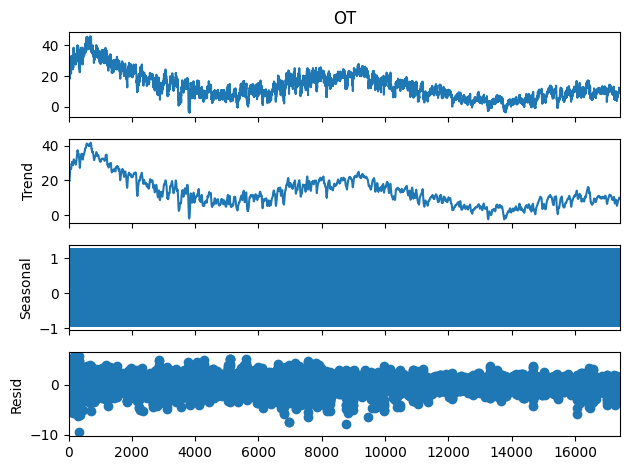

In [11]:
#1-3. 전처리 후 재분석
print(df.describe())
print(adfuller(df['OT']))
seasonal_decompose(df['OT'], model='additive', period=24).plot()
plt.show()

# [1-3 재분석 결과 — 원본과 비교]
# - describe: 원본과 거의 동일 (OT 평균 13.3, std 8.55)
#   → 보간값이 주변값 근처라 통계량 안 흔들림, 분포 왜곡 없음
# - ADF: p=0.0082 (원본 0.0056), 여전히 정상
#   → 보간 후에도 정상성 유지
# - decompose: 보간 후에도 24시간 기준 분해에서 trend가 크고 seasonal은 작음
#   → gap 복원이 24시간 주기 성분을 크게 바꾸진 않음
#   (단, 주간(168h) 등 다른 주기는 확인 안 함 → "계절성 약함"은 24h 기준 한정)
# 핵심: 보간이 분포를 왜곡하지 않았음을 확인 (통계량, 정상성 유지)

In [12]:
#################### EDIT YOUR CODE #########################
class TSDataset(Dataset):
    """window_size 입력 → pred_len 예측. gap 걸친 윈도우는 제외(1-7)."""
    def __init__(self, data, stamp, boundary, border1, border2,
                 window_size, label_len, pred_len):
        self.data = data
        self.stamp = stamp
        self.window_size = window_size
        self.label_len = label_len
        self.pred_len = pred_len

        self.starts = []
        last = border2 - (window_size + pred_len) + 1
        for s in range(border1, last):
            e = s + window_size + pred_len
            if not boundary[s:e].any():        # gap 걸친 윈도우 제외 (1-7)
                self.starts.append(s)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = self.starts[idx]              # 유효한 시작점 하나 꺼냄
        s_end = s + self.window_size      # 입력 끝 = 시작 + 96
        r_beg = s_end - self.label_len    # label_len=0이라 r_beg = s_end
        r_end = s_end + self.pred_len     # 예측 끝 = 입력끝 + 96
        seq_x      = self.data[s:s_end]       # 입력: 96시간 [96, 7]
        seq_y      = self.data[r_beg:r_end]   # 정답: 다음 96시간 [96, 7]
        seq_x_mark = self.stamp[s:s_end]      # 입력 구간 시간피처
        seq_y_mark = self.stamp[r_beg:r_end]  # 정답 구간 시간피처
        return seq_x, seq_y, seq_x_mark, seq_y_mark


def create_dataloader_default(
        task_name: str,
        data_name: str,
        sub_data_name: str,
        data_info: dict,
        train_setting: dict,
        scaler: str,
        window_size: int,
        label_len: int,
        pred_len: int,
        model_type: str,
        split_rate: list,
        timeenc: int,
        freq: str
        ):

    # 1) 로드 + 보간 (1-2)
    df = pd.read_csv(data_info.datadir)
    df['date'] = pd.to_datetime(df['date'])
    full_range = pd.date_range(df['date'].min(), df['date'].max(), freq=freq)
    df = df.set_index('date').reindex(full_range)
    was_missing = df['OT'].isna().values
    df = df.interpolate(method='linear')

    # 긴 gap(>8h) 구간 boundary 표시 (1-7)
    boundary = np.zeros(len(df), dtype=bool)
    i, n = 0, len(df)
    while i < n:
        if was_missing[i]:
            j = i
            while j < n and was_missing[j]:
                j += 1
            if (j - i) >= 8:
                boundary[i:j] = True
            i = j
        else:
            i += 1

    # 2) 변수 + 시간피처
    cols = df.columns.tolist()
    data_raw = df[cols].values
    stamp = pd.DataFrame({'date': full_range})
    stamp['month']   = stamp.date.dt.month
    stamp['day']     = stamp.date.dt.day
    stamp['weekday'] = stamp.date.dt.weekday
    stamp['hour']    = stamp.date.dt.hour
    data_stamp = stamp[['month', 'day', 'weekday', 'hour']].values

    # 3) split
    n_train = int(n * split_rate[0])
    n_val   = int(n * split_rate[1])
    border1s = [0, n_train - window_size, n_train + n_val - window_size]
    border2s = [n_train, n_train + n_val, n]
    # valid/test 시작을 window_size만큼 앞당김:
    # 각 split 첫 시점을 예측하려면 앞선 96시간(입력 문맥)이 필요하기 때문.
    # 이 구간은 입력으로만 쓰고 정답 아님 + scaler는 train만 fit → 누수 없음

    # 4) 정규화 (train만 fit)
    if scaler == "standard":
        sc = StandardScaler()
        sc.fit(data_raw[border1s[0]:border2s[0]])
        data = sc.transform(data_raw)
    else:
        data = data_raw

    # 5) Dataset
    def make(split):
        return TSDataset(data, data_stamp, boundary,
                         border1s[split], border2s[split],
                         window_size, label_len, pred_len)
    trn_set, val_set, test_set = make(0), make(1), make(2)

    # 6) DataLoader
    trn_loader = DataLoader(trn_set, batch_size=train_setting.batch_size,
                            shuffle=train_setting.shuffle,
                            num_workers=train_setting.num_workers,
                            pin_memory=train_setting.pin_memory, drop_last=True)
    val_loader = DataLoader(val_set, batch_size=train_setting.test_batch_size,
                            shuffle=False, num_workers=train_setting.num_workers,
                            pin_memory=train_setting.pin_memory, drop_last=False)
    test_loader = DataLoader(test_set, batch_size=train_setting.test_batch_size,
                             shuffle=False, num_workers=train_setting.num_workers,
                             pin_memory=train_setting.pin_memory, drop_last=False)

    # 7) 반환
    information_dict = {'enc_in': data.shape[1], 'c_out': data.shape[1]}
    return information_dict, trn_loader, val_loader, test_loader
    #############################################################

In [13]:
# load and define dataloader
information_dict, trn_dataloader, valid_dataloader, test_dataloader = create_dataloader_default(
            task_name         = cfg.DATASET.taskname,
            data_name         = cfg.DATASET.dataname,
            sub_data_name     = cfg.DATASET.sub_data_name,
            data_info         = cfg.DATAINFO,
            train_setting     = cfg.TRAIN,
            scaler            = cfg.DATASET.scaler,
            window_size       = cfg.DATASET.window_size,
            label_len         = cfg.DATASET.label_len,
            pred_len          = cfg.DATASET.pred_len,
            model_type        = cfg.DATASET.model_type,
            split_rate        = cfg.DATASET.split_rate,
            timeenc           = cfg.DATASET.timeenc,
            freq              = cfg.DATASET.freq
            )


In [14]:
# Update dataset information to cfg

def update_information(model_name, cfg, information_dict):
    dataset_attrs = ['window_size', 'label_len', 'pred_len', 'taskname',
                     'pretrain', 'timeenc', 'freq', 'embed_type']

    for attr in dataset_attrs:
        setattr(cfg.MODELSETTING, attr, getattr(cfg.DATASET, attr))

    cfg.MODELSETTING.batch_size = cfg.TRAIN.batch_size

    model_attrs = ['enc_in', 'c_out']
    for attr in model_attrs:
        if attr in information_dict:
            setattr(cfg.MODELSETTING, attr, information_dict[attr])


update_information(model_name        = cfg.MODEL.modelname,
                    cfg              = cfg,
                    information_dict = information_dict)

## 2. 모델 구축

    2-1) 시계열 예측이 가능한 모델 형태 임의로 구성하여 사용. 기존 모델을 사용하는 경우 재현하여 사용할 것
    2-2) 모델의 입력부터 출력까지 모든 변화 중 모델의 차원 형태 변화 기재

In [15]:
################### EDIT YOUR CODE #########################
class moving_avg(nn.Module):
    # 이동평균으로 추세(trend) 추출
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # 양끝 패딩(경계 손실 방지)
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x

class series_decomp(nn.Module):
    # 시계열을 추세 + 계절성으로 분해
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

class DLinear(nn.Module):
    # DLinear: 분해 후 각 성분을 Linear로 예측 (Zeng et al. 2023 재현)
    def __init__(self, configs, individual=True):
        super().__init__()
        self.task_name = configs.taskname
        self.window_size = configs.window_size
        self.pred_len = configs.pred_len
        self.channels = configs.enc_in          # 변수 수 = 7

        self.decomp = series_decomp(configs.moving_avg)  # 분해 커널
        self.individual = individual

        if self.individual:
            # 변수마다 별도 Linear
            self.Linear_Seasonal = nn.ModuleList(
                [nn.Linear(self.window_size, self.pred_len) for _ in range(self.channels)])
            self.Linear_Trend = nn.ModuleList(
                [nn.Linear(self.window_size, self.pred_len) for _ in range(self.channels)])
        else:
            # 전 변수 공유 Linear
            self.Linear_Seasonal = nn.Linear(self.window_size, self.pred_len)
            self.Linear_Trend = nn.Linear(self.window_size, self.pred_len)

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        if self.task_name == 'long_term_forecast':
            # x_enc: [B, window, C]
            seasonal, trend = self.decomp(x_enc)         # 각 [B, window, C]
            # Linear는 시간축에 적용 → [B, C, window]로 transpose
            seasonal = seasonal.permute(0, 2, 1)         # [B, C, window]
            trend = trend.permute(0, 2, 1)               # [B, C, window]

            if self.individual:
                s_out = torch.zeros([seasonal.size(0), self.channels, self.pred_len],
                                    device=x_enc.device)
                t_out = torch.zeros([trend.size(0), self.channels, self.pred_len],
                                    device=x_enc.device)
                for i in range(self.channels):
                    s_out[:, i, :] = self.Linear_Seasonal[i](seasonal[:, i, :])
                    t_out[:, i, :] = self.Linear_Trend[i](trend[:, i, :])
                seasonal, trend = s_out, t_out
            else:
                seasonal = self.Linear_Seasonal(seasonal)  # [B, C, pred]
                trend = self.Linear_Trend(trend)           # [B, C, pred]

            output = seasonal + trend                    # [B, C, pred]
            output = output.permute(0, 2, 1)             # [B, pred, C]
            return output[:, -self.pred_len:, :]
        return None
############################################################

In [16]:
################### EDIT YOUR CODE #########################
class NLinear(nn.Module):
    # NLinear: 입력 마지막값을 빼고 Linear 예측 후 다시 더함.
    # 분포 변화(shift)에 강건. (Zeng et al. 2023 재현)
    def __init__(self, configs, individual=False):
        super().__init__()
        self.task_name = configs.taskname
        self.window_size = configs.window_size
        self.pred_len = configs.pred_len
        self.channels = configs.enc_in
        self.individual = individual

        if self.individual:
            self.Linear = nn.ModuleList(
                [nn.Linear(self.window_size, self.pred_len) for _ in range(self.channels)])
        else:
            self.Linear = nn.Linear(self.window_size, self.pred_len)

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        if self.task_name == 'long_term_forecast':
            # x_enc: [B, window, C]
            seq_last = x_enc[:, -1:, :].detach()   # 마지막 시점값 [B,1,C]
            x = x_enc - seq_last                    # 마지막값 기준으로 정규화
            x = x.permute(0, 2, 1)                  # [B, C, window]

            if self.individual:
                out = torch.zeros([x.size(0), self.channels, self.pred_len],
                                  device=x_enc.device)
                for i in range(self.channels):
                    out[:, i, :] = self.Linear[i](x[:, i, :])
                x = out
            else:
                x = self.Linear(x)                  # [B, C, pred]

            x = x.permute(0, 2, 1)                  # [B, pred, C]
            x = x + seq_last                        # 뺐던 마지막값 복원
            return x[:, -self.pred_len:, :]
        return None
############################################################

In [17]:
################### EDIT YOUR CODE #########################
class SimpleMLP(nn.Module):
    # 비선형 MLP: window→hidden→pred. 채널 공유, 시간축에 적용
    def __init__(self, configs, individual=False):
        super().__init__()
        self.task_name = configs.taskname
        self.window_size = configs.window_size
        self.pred_len = configs.pred_len
        self.channels = configs.enc_in

        hidden = getattr(configs, 'hidden', 256)  # 은닉층 크기
        self.net = nn.Sequential(
            nn.Linear(self.window_size, hidden),
            nn.ReLU(),
            nn.Dropout(getattr(configs, 'dropout', 0.1)),
            nn.Linear(hidden, self.pred_len),
        )

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        if self.task_name == 'long_term_forecast':
            # 마지막값 정규화(NLinear 아이디어 차용, 안정성)
            seq_last = x_enc[:, -1:, :].detach()
            x = (x_enc - seq_last).permute(0, 2, 1)  # [B, C, window]
            x = self.net(x)                          # [B, C, pred]
            x = x.permute(0, 2, 1) + seq_last        # [B, pred, C]
            return x[:, -self.pred_len:, :]
        return None
############################################################

In [18]:
################### EDIT YOUR CODE #########################
import torch
import torch.nn as nn

class PatchTST(nn.Module):
    # PatchTST 재현: 채널독립 + 패칭 + 트랜스포머 인코더 (Nie et al. 2023)
    def __init__(self, configs, individual=False):
        super().__init__()
        self.task_name = configs.taskname
        self.window_size = configs.window_size
        self.pred_len = configs.pred_len
        self.channels = configs.enc_in

        # 패칭 설정
        self.patch_len = getattr(configs, 'patch_len', 16)
        self.stride    = getattr(configs, 'stride', 8)
        d_model  = getattr(configs, 'd_model', 128)
        n_heads  = getattr(configs, 'n_heads', 8)
        n_layers = getattr(configs, 'e_layers', 3)
        d_ff     = getattr(configs, 'd_ff', 256)
        dropout  = getattr(configs, 'dropout', 0.1)

        # 패치 개수 계산 (마지막에 stride만큼 패딩)
        self.patch_num = (self.window_size - self.patch_len) // self.stride + 2
        self.pad = nn.ReplicationPad1d((0, self.stride))  # 끝 패딩

        # 패치 → d_model 임베딩
        self.embed = nn.Linear(self.patch_len, d_model)
        self.pos = nn.Parameter(torch.randn(self.patch_num, d_model) * 0.02)
        self.drop = nn.Dropout(dropout)

        # 트랜스포머 인코더
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # flatten → 예측
        self.head = nn.Linear(d_model * self.patch_num, self.pred_len)

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        if self.task_name == 'long_term_forecast':
            # x_enc: [B, window, C]
            B, L, C = x_enc.shape

            # 채널독립: [B,L,C] → [B*C, L]  (각 변수를 독립 시퀀스로)
            x = x_enc.permute(0, 2, 1).reshape(B * C, L)

            # 인스턴스 정규화 (변수별 평균/표준편차 제거, 예측 후 복원)
            mean = x.mean(dim=1, keepdim=True)
            std = x.std(dim=1, keepdim=True) + 1e-5
            x = (x - mean) / std

            # 패칭: [B*C, L] → [B*C, patch_num, patch_len]
            x = self.pad(x.unsqueeze(1)).squeeze(1)     # 끝 패딩
            x = x.unfold(dimension=1, size=self.patch_len, step=self.stride)

            # 임베딩 + 위치정보
            x = self.embed(x) + self.pos                # [B*C, patch_num, d_model]
            x = self.drop(x)

            # 트랜스포머 인코더
            x = self.encoder(x)                         # [B*C, patch_num, d_model]

            # flatten → 예측
            x = x.reshape(B * C, -1)                    # [B*C, patch_num*d_model]
            x = self.head(x)                            # [B*C, pred_len]

            # 정규화 복원
            x = x * std + mean

            # [B*C, pred] → [B, pred, C]
            x = x.reshape(B, C, self.pred_len).permute(0, 2, 1)
            return x[:, -self.pred_len:, :]
        return None
############################################################

In [19]:
def create_model(modelname: str, params: dict):
    model_classes = globals()

    if modelname not in model_classes:
        raise ValueError(f"Model '{modelname}' not found. Make sure the class is defined or imported.")

    model_class = model_classes[modelname]
    if not callable(model_class):
        raise TypeError(f"'{modelname}' is not callable. Ensure it is a valid class or function.")

    return model_class(params)

def create_criterion(loss_name: str, params: dict = {}):
    loss_classes = vars(__import__('torch.nn', fromlist=[''])).get(loss_name)
    return loss_classes(**params)

def create_optimizer(model, opt_name: str, lr: float, params: dict = {}):
    opt_classes = vars(__import__('torch.optim', fromlist=[''])).get(opt_name)
    return opt_classes(model.parameters(), lr=lr, **params)

# build Model
model = create_model(
    modelname    = cfg.MODEL.modelname,
    params       = cfg.MODELSETTING
    )

# set training
criterion = create_criterion(loss_name=cfg.LOSS.loss_name)
optimizer = create_optimizer(model=model, opt_name=cfg.OPTIMIZER.opt_name, lr=cfg.OPTIMIZER.lr, params=cfg.OPTIMIZER.params)

print('# of learnable params: {}'.format(np.sum([p.numel() if p.requires_grad else 0 for p in model.parameters()])))

# of learnable params: 548704


In [20]:
model, optimizer, trn_dataloader, valid_dataloader, test_dataloader = accelerator.prepare(
    model, optimizer, trn_dataloader, valid_dataloader, test_dataloader
)

## 3. 모델 학습 및 테스트
    3-1) 수정 내용을 반영하며, 학습 및 테스트 코드에 기술된 argument가 포함될 수 있도록 함수 작성
    3-2) Argument가 기재된 의도를 파악하여 최대한 많은 argument사용하여 작성

In [21]:
class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

################### EDIT YOUR CODE #########################
def adjust_learning_rate(optimizer, epoch, lradj, learning_rate):
    # lradj='type1': 매 epoch마다 lr 절반씩 감소
    if lradj == 'type1':
        lr = learning_rate * (0.5 ** ((epoch - 1) // 1))
    elif lradj == 'type2':
        lr = learning_rate * (0.5 ** ((epoch - 1) // 2))
    else:
        lr = learning_rate
    for pg in optimizer.param_groups:
        pg['lr'] = lr


def training_long_term_forecasting(
    model, trainloader, validloader, criterion, optimizer, accelerator,
    epochs, eval_epochs, log_epochs, log_eval_iter, wandb_iter,
    use_wandb, ckp_metric, savedir, model_name,
    pred_len, label_len, early_stopping_metric, early_stopping_count,
    lradj, learning_rate, model_config):

    # accelerator가 모델/옵티마/로더를 device에 맞게 준비
    model, optimizer, trainloader, validloader = accelerator.prepare(
        model, optimizer, trainloader, validloader)

    best_score = float('inf')
    patience = 0

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        train_loss = AverageMeter()
        for seq_x, seq_y, seq_x_mark, seq_y_mark in trainloader:
            seq_x = seq_x.float(); seq_y = seq_y.float()
            seq_x_mark = seq_x_mark.float(); seq_y_mark = seq_y_mark.float()

            optimizer.zero_grad()
            output = model(seq_x, seq_x_mark, seq_y, seq_y_mark)  # [B, pred, C]
            loss = criterion(output, seq_y)                      # label_len=0 → seq_y가 pred
            accelerator.backward(loss)
            optimizer.step()
            train_loss.update(loss.item(), seq_x.size(0))

        # valid
        model.eval()
        valid_loss = AverageMeter()
        with torch.no_grad():
            for seq_x, seq_y, seq_x_mark, seq_y_mark in validloader:
                seq_x = seq_x.float(); seq_y = seq_y.float()
                seq_x_mark = seq_x_mark.float(); seq_y_mark = seq_y_mark.float()
                output = model(seq_x, seq_x_mark, seq_y, seq_y_mark)
                loss = criterion(output, seq_y)
                valid_loss.update(loss.item(), seq_x.size(0))

        if epoch % log_epochs == 0:
              accelerator.print(f'Epoch [{epoch}/{epochs}] '
                      f'train {train_loss.avg:.4f} | valid {valid_loss.avg:.4f}')

        # checkpoint (valid loss 개선 저장)
        score = valid_loss.avg
        if score < best_score:
            best_score = score
            patience = 0
            accelerator.wait_for_everyone()
            if accelerator.is_main_process:
                torch.save(model.state_dict(), os.path.join(savedir, 'best_model.pt'))
        else:
            patience += 1
            if patience >= early_stopping_count:
                accelerator.print(f'Early stopping at epoch {epoch}')
                break

        # lr 조정
        adjust_learning_rate(optimizer, epoch, lradj, learning_rate)


def test_long_term_forecasting(model, dataloader, criterion, accelerator,
                                log_interval, pred_len, label_len, savedir, model_config,
                                model_name, name, return_output):
    model, dataloader = accelerator.prepare(model, dataloader)
    model.eval()

    preds, trues = [], []
    with torch.no_grad():
        for seq_x, seq_y, seq_x_mark, seq_y_mark in dataloader:
            seq_x = seq_x.float(); seq_y = seq_y.float()
            seq_x_mark = seq_x_mark.float(); seq_y_mark = seq_y_mark.float()
            output = model(seq_x, seq_x_mark, seq_y, seq_y_mark)
            preds.append(output.cpu().numpy())
            trues.append(seq_y.cpu().numpy())

    preds = np.concatenate(preds, axis=0)   # [N, pred, C]
    trues = np.concatenate(trues, axis=0)

    mse = np.mean((preds - trues) ** 2)
    mae = np.mean(np.abs(preds - trues))
    accelerator.print(f'[{name}] MSE: {mse:.4f} | MAE: {mae:.4f}')

    metrics = {'MSE': float(mse), 'MAE': float(mae)}
    if return_output:
        # 4번(시각화)에서 쓰려고 예측/실제 저장
        np.save(os.path.join(savedir, 'pred.npy'), preds)
        np.save(os.path.join(savedir, 'true.npy'), trues)
    return metrics
############################################################

In [22]:
if cfg.DATASET.taskname == 'long_term_forecast':
    # fitting model
    training_long_term_forecasting(
    model                 = model,
    trainloader           = trn_dataloader,
    validloader           = valid_dataloader,
    criterion             = criterion,
    optimizer             = optimizer,
    accelerator           = accelerator,
    epochs                = cfg.TRAIN.epoch,
    eval_epochs           = cfg.TRAIN.eval_epochs,
    log_epochs            = cfg.TRAIN.log_epochs,
    log_eval_iter         = cfg.TRAIN.log_eval_iter,
    use_wandb             = cfg.TRAIN.wandb.use,
    wandb_iter            = cfg.TRAIN.wandb.iter,
    ckp_metric            = cfg.TRAIN.ckp_metric,
    label_len             = cfg.DATASET.label_len,
    pred_len              = cfg.DATASET.pred_len,
    savedir               = savedir,
    model_name            = cfg.MODEL.modelname,
    early_stopping_metric = cfg.TRAIN.early_stopping_metric,
    early_stopping_count  = cfg.TRAIN.early_stopping_count,
    lradj                 = cfg.TRAIN.lradj,
    learning_rate         = cfg.OPTIMIZER.lr,
    model_config          = cfg.MODELSETTING
    )

    # load best checkpoint weights
    model.load_state_dict(torch.load(os.path.join(savedir, 'best_model.pt')))

    # test results
    fine_tuning_test_metrics = test_long_term_forecasting(
    accelerator   = accelerator,
    model         = model,
    dataloader    = test_dataloader,
    criterion     = criterion,
    log_interval  = cfg.TRAIN.log_eval_iter,
    label_len     = cfg.DATASET.label_len,
    pred_len      = cfg.DATASET.pred_len,
    name          = 'TEST',
    savedir       = savedir,
    model_name    = cfg.MODEL.modelname,
    model_config  = cfg.MODELSETTING,
    return_output = cfg.TRAIN.return_output
    )

Epoch [1/30] train 0.4729 | valid 0.3824
Epoch [2/30] train 0.4247 | valid 0.3738
Epoch [3/30] train 0.4128 | valid 0.3596
Epoch [4/30] train 0.4068 | valid 0.3511
Epoch [5/30] train 0.4044 | valid 0.3491
Epoch [6/30] train 0.4027 | valid 0.3485
Epoch [7/30] train 0.4020 | valid 0.3482
Epoch [8/30] train 0.4018 | valid 0.3480
Epoch [9/30] train 0.4015 | valid 0.3479
Epoch [10/30] train 0.4016 | valid 0.3479
Epoch [11/30] train 0.4013 | valid 0.3479
Epoch [12/30] train 0.4013 | valid 0.3478
Epoch [13/30] train 0.4013 | valid 0.3478
Epoch [14/30] train 0.4013 | valid 0.3478
Epoch [15/30] train 0.4013 | valid 0.3478
Epoch [16/30] train 0.4013 | valid 0.3478
Epoch [17/30] train 0.4012 | valid 0.3478
Epoch [18/30] train 0.4013 | valid 0.3478
Epoch [19/30] train 0.4013 | valid 0.3478
Epoch [20/30] train 0.4014 | valid 0.3478
Epoch [21/30] train 0.4011 | valid 0.3478
Epoch [22/30] train 0.4012 | valid 0.3478
Epoch [23/30] train 0.4013 | valid 0.3478
Epoch [24/30] train 0.4014 | valid 0.3478
E

In [23]:
import json
import numpy as np

class Float32Encoder(json.JSONEncoder):
    # numpy float32/int 등을 json이 저장 가능한 파이썬 타입으로 변환
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

In [24]:
accelerator.wait_for_everyone()
if accelerator.is_main_process:
    _logger.info('{} test_metrics: {}'.format(cfg.DATASET.taskname, fine_tuning_test_metrics))
    json.dump(fine_tuning_test_metrics, open(os.path.join(savedir,
                        f'{cfg.DATASET.taskname}test_results.json'),'w'), indent='\t', cls=Float32Encoder)

In [25]:
print(os.listdir(savedir))

['best_model.pt', 'pred.npy', 'true.npy', 'long_term_forecasttest_results.json']


In [26]:
pred = np.load(os.path.join(savedir, 'pred.npy'))
true = np.load(os.path.join(savedir, 'true.npy'))

mse = np.mean((pred - true) ** 2)
mae = np.mean(np.abs(pred - true))
print(f'pred shape: {pred.shape}')
print(f'MSE: {mse:.4f}, MAE: {mae:.4f}')

pred shape: (1532, 96, 7)
MSE: 0.5079, MAE: 0.5025


## 4. 성능 평가 및 결과 해석
    4-1) 저장된 내용을 바탕으로 각 평가 지표의 결과 비교 및 분석
    4-2) 실제값과 예측값 시각화하여 결과 비교
    4-3) 모델의 한계점과 개선 방향 제시


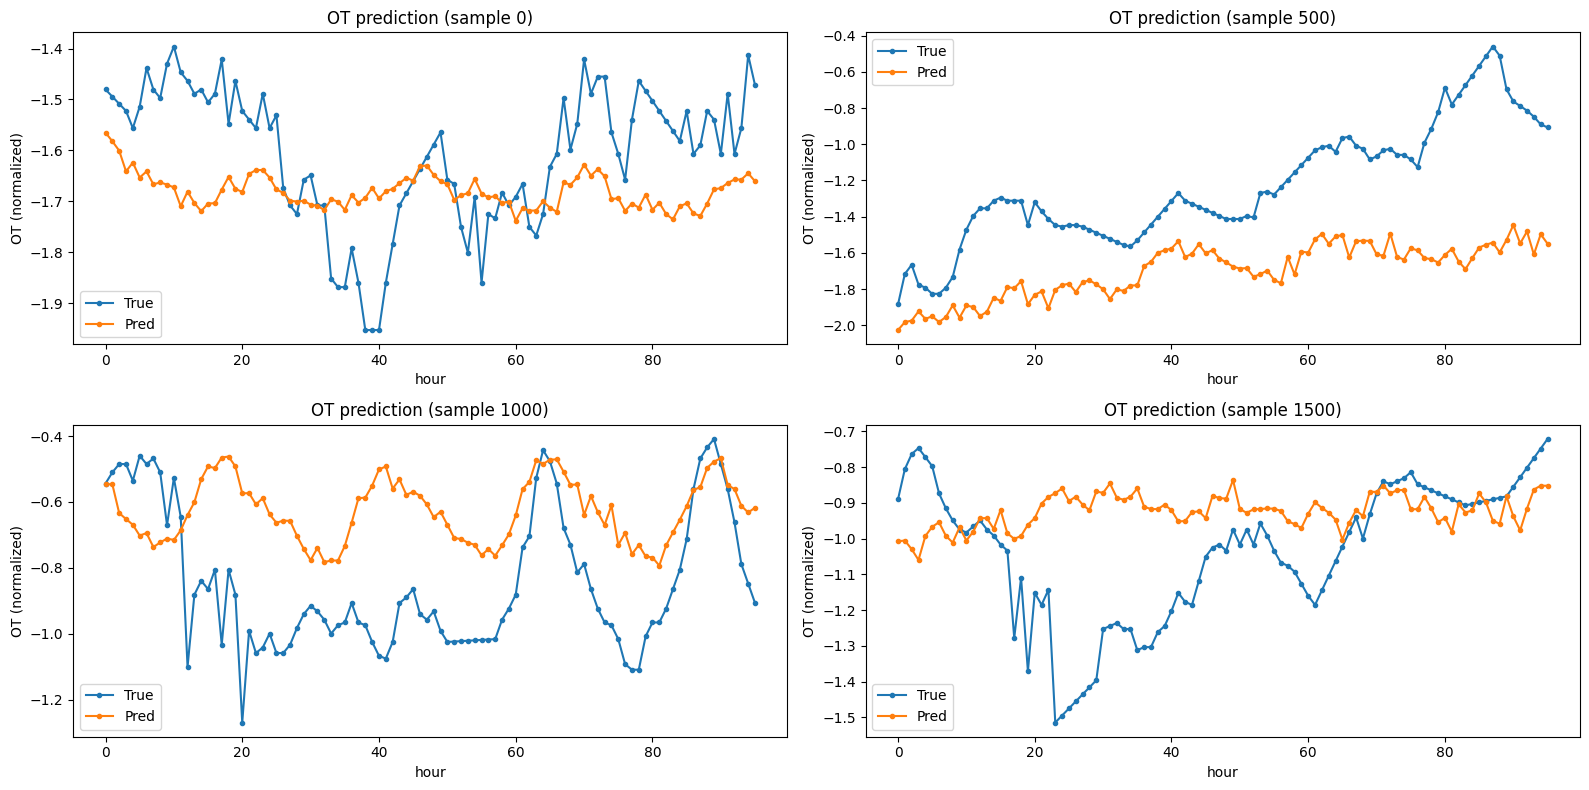

MSE: 0.5079, MAE: 0.5025


In [27]:
# 4-1~3 항목의 EDA 코드 작성
################### EDIT YOUR CODE #########################
pred = np.load(os.path.join(savedir, 'pred.npy'))
true = np.load(os.path.join(savedir, 'true.npy'))

# OT = 마지막 컬럼(index 6). 샘플 몇 개 골라서 비교
samples = [0, 500, 1000, 1500]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, s in zip(axes.flat, samples):
    ax.plot(true[s, :, 6], label='True', marker='.')
    ax.plot(pred[s, :, 6], label='Pred', marker='.')
    ax.set_title(f'OT prediction (sample {s})')
    ax.set_xlabel('hour'); ax.set_ylabel('OT (normalized)')
    ax.legend()
plt.tight_layout()
plt.show()

# 지표 재확인
mse = np.mean((pred - true) ** 2)
mae = np.mean(np.abs(pred - true))
print(f'MSE: {mse:.4f}, MAE: {mae:.4f}')

# [4-1] 모델별 성능 비교 (동일 전처리/학습설정, modelname만 변경하여 실험)
# 모델            MSE      MAE     인접차(톱니)   특징
# DLinear(공유)   0.596    0.554   0.115         분해+공유Linear
# DLinear(개별)   0.754    0.640   0.359         분해+개별, 톱니 폭발
# NLinear         0.859    0.660   심함          마지막값 의존, 최악
# MLP             0.637    0.569   0.055         비선형 통짜, 톱니 없음
# PatchTST        0.508    0.502   0.033         패칭+어텐션, 최종 선택
#
# 해석:
# - MSE 최저 = PatchTST(0.508). 원본 ETTh1(약 0.38)보다 높으나,
#   결측 있는 adjust + pred_len 96 조건이라 직접 비교는 부적절.
# - 트레이드오프: DLinear는 MSE 중간이나 톱니 심함,
#   MLP는 톱니 없으나 MSE 아쉬움. PatchTST만 둘 다 잡음.

############################################################

In [28]:
import numpy as np
import os

pred = np.load(os.path.join(savedir, 'pred.npy'))
true = np.load(os.path.join(savedir, 'true.npy'))

# OT(index 6) 인접 시점 차이 = 톱니 정도
print("pred 인접차 평균:", np.mean(np.abs(np.diff(pred[:, :, 6], axis=1))))
print("true 인접차 평균:", np.mean(np.abs(np.diff(true[:, :, 6], axis=1))))
print("MSE:", np.mean((pred - true) ** 2), " MAE:", np.mean(np.abs(pred - true)))

# [예측 매끄러움 지표 = 인접 시점 차이 평균]
# 예측이 인접 시점마다 과도하게 튀는지(본 분석에선 '톱니'로 표현) 정량화.
# = mean(|pred[t] - pred[t-1]|). 실제값의 인접차보다 크면 과도한 진동.
# pred 0.033 ≈ true 0.051 → PatchTST는 실제만큼 매끄러움

# [톱니 지표 = 인접 시점 차이 평균]
# 예측이 계단처럼 튀는지(톱니), 실제처럼 연속적인지 정량화하는 지표.
# pred 인접차가 true보다 크면 예측이 과도하게 요동친다는 뜻.
# PatchTST: pred 0.033 ≈ true 0.051 → 실제만큼 매끄러움 (톱니 없음)

pred 인접차 평균: 0.033177763
true 인접차 평균: 0.05080892
MSE: 0.50787485  MAE: 0.5024546


In [29]:
# [4-3] 한계점 및 개선 방향
#
# 한계:
# - 큰 변동(봉우리/골짜기) 과소예측: pred 표준편차 < true.
#   급격한 피크를 완만하게 예측하는 경향 (모든 모델 공통)
# - gap 경계 오염: boundary는 gap 직접 접촉 window만 제외.
#   gap 직후 시작 window는 보간값 영향 일부 잔존 (학습량과의 타협)
# - 하이퍼파라미터 미튜닝: patch_len, lr, epoch 등 기본값 사용
# - 변수별 성능 미분석: 전체 평균 MSE만 봄 (변수별 편차 가능)
# - 계절성 24h 기준만 확인: 주간(168h) 등 다른 주기 미검증
#
# 개선 방향:
# - window 확대(96→336): 더 긴 문맥으로 큰 변동 포착
# - 피크 구간 가중 손실: OT 상한 이상치(실제 신호) 예측 강화
# - 하이퍼파라미터 튜닝 (grid search)
# - 시간피처(시간대/요일) 활용: 현재 생성만 하고 모델이 미사용